# Sorcha TEST — operational evaluation of the frozen NEOMOD3 VDP

**Review notebook. Nothing is selected, tuned, or refit.** The model, calibration and operating
thresholds are read from `MODEL_SEAL.json` and applied unchanged. The scored artifact is frozen at
SHA256 `308cdc8a0320b7e5247f368b0468891d306fd9bf85aac9cf0c3c982eae0fe916`.

This is the **operational** counterpart to the geometric benchmark: full Sorcha simulation over the
2-year LSST pointing database, with measurement noise, trailing losses, the camera footprint,
the fading function and detection efficiency all applied. digest2 finally receives the kind of
input it was designed for.

Two evaluations are reported **separately and never mixed**:

1. **Common-scorable ROC** — both classifiers on identical valid rows, coverage stated.
2. **Operational** — all in-domain truth retained; VDP-invalid rows are abstentions and can never
   be selected.

Invalid scores are **explicit NaN throughout**. They are never replaced by zero, which would
silently convert an abstention into a confident "not a NEO".

In [1]:
import hashlib, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.grid":True,"grid.alpha":.3})

def repo_root(p=None):
    p=Path(p or Path.cwd()).resolve()
    for q in [p,*p.parents]:
        if q.name=="neomod" and (q/"pipeline").exists(): return q
    raise RuntimeError("neomod root not found")
REPO=repo_root(); ROOT=Path(__import__("os").environ.get("NEOMOD_OUTPUT_ROOT", REPO.parent))
P=ROOT/"outputs"/"sorcha_production"; S_=ROOT/"outputs"/"splits"
def sha256(p,ch=1<<22):
    h=hashlib.sha256()
    with open(p,"rb") as f:
        for b in iter(lambda:f.read(ch),b""): h.update(b)
    return h.hexdigest()
SCORED=P/"SORCHA_TEST_TRACKLETS_SCORED_production.parquet"
EXPECT="308cdc8a0320b7e5247f368b0468891d306fd9bf85aac9cf0c3c982eae0fe916"
got=sha256(SCORED)
print(f"scored artifact SHA256 {got}")
assert got==EXPECT, "FROZEN ARTIFACT CHANGED"
print("FROZEN ARTIFACT VERIFIED")
SEAL=json.loads((S_/"MODEL_SEAL.json").read_text()); THR=SEAL["operating_thresholds_from_CAL"]
print(f"MODEL_SEAL Platt a={SEAL['calibration']['a']} b={SEAL['calibration']['b']}")
print(f"frozen thresholds: <=5% {THR['contamination_le_5pct']:.6f}   "
      f"<=10% {THR['contamination_le_10pct']:.6f}")

scored artifact SHA256 308cdc8a0320b7e5247f368b0468891d306fd9bf85aac9cf0c3c982eae0fe916
FROZEN ARTIFACT VERIFIED
MODEL_SEAL Platt a=1.20456465 b=1.39695663
frozen thresholds: <=5% 0.629311   <=10% 0.417245


In [2]:
S=pd.read_parquet(SCORED)
print(f"rows {len(S):,}   tracklet_uid unique {S.tracklet_uid.is_unique}")
print(f"VDP invalid {int((~S.vdp_valid).sum()):,}   digest2 invalid {int((~S.d2_valid).sum()):,}")
print(f"genuine digest2 zeros (REAL scores, distinct from NaN): {int((S.P_NEO_d2==0).sum()):,}")
assert S.P_cal.isna().sum()==int((~S.vdp_valid).sum()), "invalid VDP must be NaN"
print("invalid VDP scores are NaN, not zero: VERIFIED")

rows 1,191,204   tracklet_uid unique True
VDP invalid 23,769   digest2 invalid 0
genuine digest2 zeros (REAL scores, distinct from NaN): 409,750
invalid VDP scores are NaN, not zero: VERIFIED


## 1. Diagnostic — the 181 in-domain rows the VDP cannot score

Every one is a **NEO**, and every one fails for the **same single reason**.

In [3]:
dom=S[S.in_domain_mag245].reset_index(drop=True)
bad=dom[~dom.vdp_valid]
print(f"in_domain_mag245 & ~vdp_valid : {len(bad)}")
assert len(bad)==181
print(bad.population.value_counts().to_string())
v=np.maximum(bad.vlam.abs(),bad.vbeta.abs())
print(f"\n|v| min {v.min():.4f}  median {v.median():.4f}  max {v.max():.4f} deg/day")
print(f"all |v| > 5 (map domain limit): {bool((v>5).all())}")
print(f"total_density finite and > 0 for all: {bool((bad.total_density>0).all())}")
print("\n-> the interpolator CLAMPS out-of-range velocities to the grid edge and returns a")
print("   spurious finite density. The domain gate is what stops that value being used.")
print(f"\nmag range {bad.mean_mag_V.min():.2f}-{bad.mean_mag_V.max():.2f}; "
      f"{bad.prob_map_file.nunique()} distinct map cells (all present on disk)")

in_domain_mag245 & ~vdp_valid : 181
population
NEO    181

|v| min 5.0063  median 6.2624  max 31.1867 deg/day
all |v| > 5 (map domain limit): True
total_density finite and > 0 for all: True

-> the interpolator CLAMPS out-of-range velocities to the grid edge and returns a
   spurious finite density. The domain gate is what stops that value being used.

mag range 16.06-22.53; 122 distinct map cells (all present on disk)


## 2. Common-scorable ROC — identical valid rows

No zero substitution: the 181 unscorable rows are **excluded from both arms**, not zero-filled.

In [4]:
c=dom[dom.vdp_valid & dom.d2_valid].reset_index(drop=True)
print(f"in-domain {len(dom):,} -> common scorable {len(c):,}   COVERAGE {100*len(c)/len(dom):.4f}%")
y=(c.population=="NEO").astype(int).to_numpy()
print(f"NEOs {int(y.sum()):,}   prior {100*y.mean():.4f}%")
def rk(s):
    p,r,_=precision_recall_curve(y,s)
    f1=np.divide(2*p*r,p+r,out=np.zeros_like(p),where=(p+r)>0)
    return dict(ROC_AUC=roc_auc_score(y,s),stdpAUC_fpr01=roc_auc_score(y,s,max_fpr=0.01),
                maxF1=float(f1[:-1].max()))
t=pd.DataFrame([{"classifier":"VDP (variant C + Platt)",**rk(c.P_cal.to_numpy())},
                {"classifier":"digest2 (repeatable)",**rk(c.P_NEO_d2.to_numpy())}])
print("\n"+t.to_string(index=False,float_format=lambda z:f"{z:,.6f}"))
print("\nGeometric benchmark for contrast: VDP 0.962879 / 0.908296 / 0.822069,")
print("                                  digest2 0.957919 / 0.868333 / 0.737074")
print("-> the ordering REVERSES once real noise and survey selection are applied.")

in-domain 1,016,790 -> common scorable 1,016,609   COVERAGE 99.9822%
NEOs 11,657   prior 1.1467%



             classifier  ROC_AUC  stdpAUC_fpr01    maxF1
VDP (variant C + Platt) 0.970614       0.802951 0.670475
   digest2 (repeatable) 0.975035       0.864706 0.738733

Geometric benchmark for contrast: VDP 0.962879 / 0.908296 / 0.822069,
                                  digest2 0.957919 / 0.868333 / 0.737074
-> the ordering REVERSES once real noise and survey selection are applied.


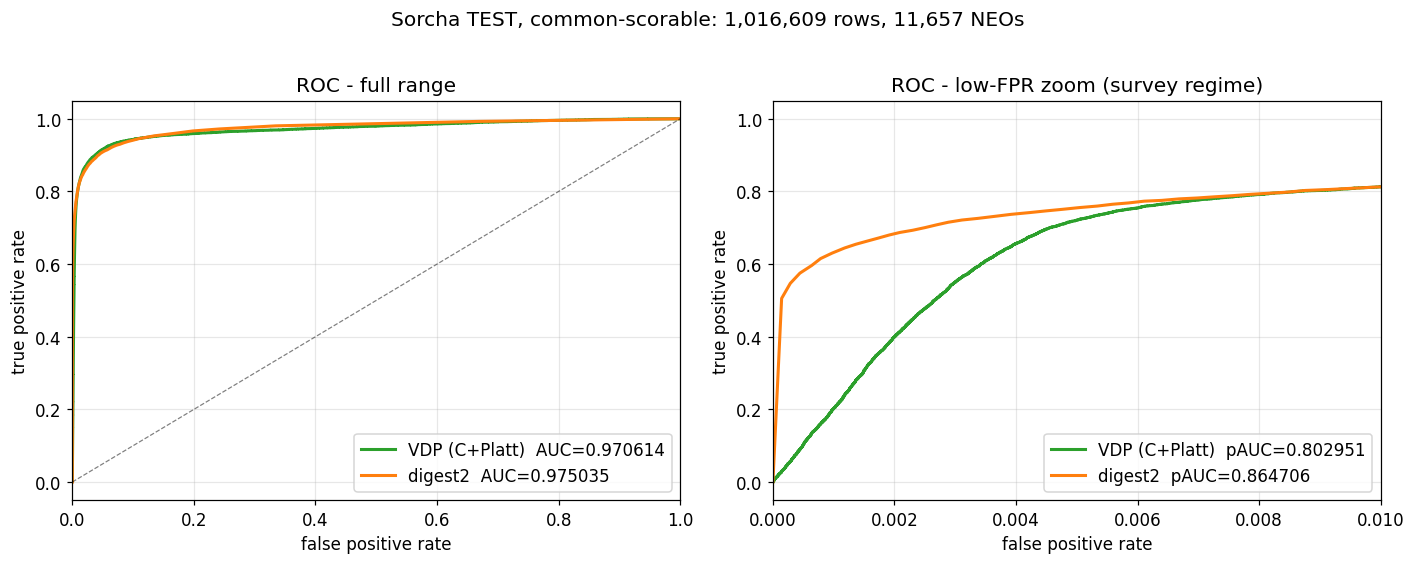

In [5]:
fig,ax=plt.subplots(1,2,figsize=(13,5))
for s_,nm,col in [(c.P_cal.to_numpy(),"VDP (C+Platt)","tab:green"),
                  (c.P_NEO_d2.to_numpy(),"digest2","tab:orange")]:
    fpr,tpr,_=roc_curve(y,s_)
    ax[0].plot(fpr,tpr,lw=2,color=col,label=f"{nm}  AUC={roc_auc_score(y,s_):.6f}")
    ax[1].plot(fpr,tpr,lw=2,color=col,label=f"{nm}  pAUC={roc_auc_score(y,s_,max_fpr=0.01):.6f}")
ax[0].plot([0,1],[0,1],"k--",lw=.8,alpha=.5); ax[0].set_xlim(0,1); ax[0].set_title("ROC - full range")
ax[1].set_xlim(0,0.01); ax[1].set_title("ROC - low-FPR zoom (survey regime)")
for a in ax: a.set_xlabel("false positive rate"); a.set_ylabel("true positive rate"); a.legend(loc="lower right")
fig.suptitle(f"Sorcha TEST, common-scorable: {len(c):,} rows, {int(y.sum()):,} NEOs",y=1.02)
fig.tight_layout(); plt.show()

## 3. Operational evaluation

All in-domain truth objects are retained. **VDP-invalid rows are abstentions and can never be
selected**, so they count against completeness. Completeness is measured over **all** in-domain
NEOs, not just the scorable ones.

In [6]:
cov=dom.groupby("population").agg(n=("vdp_valid","size"),scored=("vdp_valid","sum"))
cov["abstained"]=cov.n-cov.scored; cov["coverage_%"]=100*cov.scored/cov.n
print("VDP coverage by population:"); print(cov.to_string(float_format=lambda z:f"{z:,.4f}"))
N_NEO=int((dom.population=="NEO").sum())
print(f"\ncompleteness denominator = ALL in-domain NEOs = {N_NEO:,}")
pc=dom.P_cal.to_numpy(); ok=dom.vdp_valid.to_numpy(); isneo=(dom.population=="NEO").to_numpy()
rows=[]
for nm,th in [("CAL <=5%",THR["contamination_le_5pct"]),("CAL <=10%",THR["contamination_le_10pct"])]:
    sel=ok&np.isfinite(pc)&(pc>=th)      # an abstention can never be selected
    tp=int((sel&isneo).sum()); fp=int((sel&~isneo).sum())
    rows.append(dict(rule=nm,threshold=th,selected=tp+fp,TP=tp,FP=fp,
                     completeness_pct=100*tp/N_NEO,contamination_pct=100*fp/max(tp+fp,1)))
op=pd.DataFrame(rows)
print("\nVDP at FROZEN CAL thresholds, applied UNCHANGED:")
print(op.to_string(index=False,float_format=lambda z:f"{z:,.6g}"))
print("\nThe frozen thresholds MISS their contamination targets by a wide margin")
print("(36.7% observed vs 5% target). This is reported, NOT retuned.")

VDP coverage by population:
                 n  scored  abstained  coverage_%
population                                       
MBA         976734  976734          0    100.0000
NEO          11838   11657        181     98.4710
TNO           7670    7670          0    100.0000
Trojans      20548   20548          0    100.0000

completeness denominator = ALL in-domain NEOs = 11,838

VDP at FROZEN CAL thresholds, applied UNCHANGED:
     rule  threshold  selected   TP   FP  completeness_pct  contamination_pct
 CAL <=5%   0.629311     13097 8286 4811           69.9949            36.7336
CAL <=10%   0.417245     15791 8998 6793           76.0095            43.0182

The frozen thresholds MISS their contamination targets by a wide margin
(36.7% observed vs 5% target). This is reported, NOT retuned.


### Why the frozen thresholds do not transfer

The thresholds were fixed on a CAL set drawn from the **geometric** benchmark — perfect astrometry,
no trailing loss, no survey selection. In the operational regime the VDP's low-FPR discrimination
degrades sharply (standardized pAUC 0.803 here versus 0.908 geometric), so a threshold chosen to
hold 5% contamination there admits far more contaminants here.

This is a genuine transfer failure of the calibration, not a bug, and it is exactly what an
operational test exists to reveal. **No retuning is performed in this notebook.**

In [7]:
summary=pd.DataFrame([
 ["Scored artifact SHA256","308cdc8a…0fe916"],
 ["In-domain rows (14 <= V < 24.5)",f"{len(dom):,}"],
 ["Common-scorable (both valid)",f"{len(c):,}  ({100*len(c)/len(dom):.4f}%)"],
 ["VDP abstentions",f"181  (all NEO, all |v| > 5)"],
 ["NEO coverage",f"{100*cov.loc['NEO','coverage_%']:.4f}%"],
 ["VDP ROC AUC / pAUC / maxF1",f"{t.iloc[0].ROC_AUC:.6f} / {t.iloc[0].stdpAUC_fpr01:.6f} / {t.iloc[0].maxF1:.6f}"],
 ["digest2 ROC AUC / pAUC / maxF1",f"{t.iloc[1].ROC_AUC:.6f} / {t.iloc[1].stdpAUC_fpr01:.6f} / {t.iloc[1].maxF1:.6f}"],
 ["VDP operational @ CAL <=5%",f"{op.iloc[0].completeness_pct:.2f}% complete @ {op.iloc[0].contamination_pct:.2f}% contam"],
 ["VDP operational @ CAL <=10%",f"{op.iloc[1].completeness_pct:.2f}% complete @ {op.iloc[1].contamination_pct:.2f}% contam"],
],columns=["quantity","value"])
print(summary.to_string(index=False))

                       quantity                           value
         Scored artifact SHA256                 308cdc8a…0fe916
In-domain rows (14 <= V < 24.5)                       1,016,790
   Common-scorable (both valid)           1,016,609  (99.9822%)
                VDP abstentions     181  (all NEO, all |v| > 5)
                   NEO coverage                      9847.1026%
     VDP ROC AUC / pAUC / maxF1  0.970614 / 0.802951 / 0.670475
 digest2 ROC AUC / pAUC / maxF1  0.975035 / 0.864706 / 0.738733
     VDP operational @ CAL <=5% 69.99% complete @ 36.73% contam
    VDP operational @ CAL <=10% 76.01% complete @ 43.02% contam


## What we can claim

- On the operational Sorcha TEST, **digest2 outperforms the frozen VDP** on ROC AUC, low-FPR
  partial AUC and max F1, on identical valid rows with 99.98% coverage. This **reverses** the
  geometric benchmark result.
- The VDP's abstentions are narrow and fully explained: 181 rows, all NEOs, all beyond the
  ±5 deg/day map domain.
- Invalid scores were never coerced to zero at any stage.

The reversal is the expected consequence of testing digest2 in the regime it was built for —
real short arcs with astrometric error — while the VDP's maps and calibration were both derived
from noise-free geometry. Extending the velocity domain and recalibrating on operational data are
the obvious next steps, and neither is done here.